# Project: Startup Market Research

## Introduction

This project focuses on analyzing the startup investment market with the goal of identifying promising companies for acquisition, development, and potential resale.

To ensure an optimal workflow, the analysis follows a structured approach. During the research process, reasoning and conclusions are documented after each major step.

General guidelines followed in this project:

Start with an introduction describing the context and objectives.

Add comments to explain the logic of the code.

Use Markdown cells to describe assumptions, decisions, and conclusions.

Provide intermediate conclusions after each major step.

**Project Goal and Objectives**
**Goal**

Conduct an exploratory data analysis of the investment market with a focus on acquiring, developing, and reselling promising startups.

**Objectives**

1. Data familiarization: loading and initial preprocessing.

2. Data cleaning and preliminary analysis.

3. Exploratory analysis of merged datasets.

4. Final conclusions and investment recommendations.**

**Datasets Used:  
company_and_rounds.csv      
acquisition.csv    
people.csv    
education.csv      
degrees.csv**    
**Dataset Description:**    
* **acquisition  
Contains information about company acquisitions:  
id — acquisition ID  
acquiring_company_id — acquiring company ID  
acquired_company_id — acquired company ID  
term_code — transaction type  
price_amount — deal amount  
acquired_at — acquisition date**  
* **company_and_rounds  
Contains information about companies and funding rounds:  
company_ID — company identifier  
name — company name  
category_code — industry category  
status — company status  
founded_at — founding date  
closed_at — closure date  
domain — official website  
network_username — social network username  
country_code — country code  
investment_rounds — number of investment rounds  
funding_rounds — number of funding rounds  
funding_total — total funding amount  
milestones — company milestones  
funding_round_id — funding round ID  
funded_at — funding date  
funding_round_type — funding type  
raised_amount — amount raised  
pre_money_valuation — pre-money valuation  
participants — number of participants  
is_first_round — whether it is the first round  
is_last_round — whether it is the last round**    
* **education  
Contains employee education data:  
id — education record ID  
person_id — employee ID  
institution — educational institution  
graduated_at — graduation date.**     
* **people  
Contains employee information:  
id — employee ID  
first_name — first name  
last_name — last name  
company_id — company ID  
network_username — social network username.    
network_username — ник в социальных сетях.**      
* **degrees  
Contains information about degree types:  
id — record ID  
object_id — employee ID  
degree_type — degree type  
subject — field of study.**   


## Step 1. Data Familiarization and Initial Preprocessing

File names:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Optional datasets:
* fund.csv
* investment.csv

In [1]:
!pip install matplotlib-venn

In [2]:
# Importing libraries
import pandas as pd

# Loading libraries for data visualization
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Constant for the data path
PATH = "https://code.s3.yandex.net/datasets/"
# Downloading data into variables acquisition_df, company_and_rounds_df, people_df, education_df, degrees_df
acquisition_df = pd.read_csv(PATH + 'acquisition.csv')
company_and_rounds_df = pd.read_csv(PATH + 'company_and_rounds.csv')
people_df = pd.read_csv(PATH + 'people.csv')
education_df = pd.read_csv(PATH + 'education.csv')
degrees_df = pd.read_csv(PATH + 'degrees.csv')

In [4]:
# Displaying information about the dataset
acquisition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


In [5]:
# Displaying information about the dataset
company_and_rounds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

In [6]:
# Displaying information about the dataset
people_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [7]:
# Displaying information about the dataset
education_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [8]:
# Displaying information about the dataset
degrees_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [9]:
# Match check
first_id = set(company_and_rounds_df['company  ID'].dropna().unique())
second_id = set(company_and_rounds_df['company  id'].dropna().unique())
print("Does it match:", first_id == second_id)

Совпадает ли: False


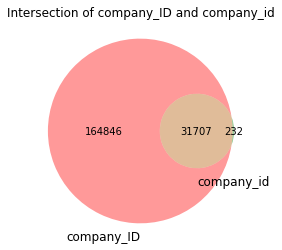

In [46]:
# Displaying the chart
venn2([first_id, second_id], set_labels=('company_ID', 'company_id'))
plt.title("Intersection of company_ID and company_id")
plt.show()

**acquisition_df: The data types are generally correct, but acquired_at is stored as an object and needs to be converted to datetime. There are missing values in term_code (80%) and in acquired_at. **
**company_and_rounds_df: There is a problem with spaces in the column names (company ID, category code, etc.), and they need to be standardized to snake_case. founded_at, closed_at, funded_at are determined as objects and need to be converted to datetime. There are two almost identical fields, company ID and company id. You can check if the values match using venn2. **
**people_df: Missing values in company_id are only present in 15% of the persons, and network_username is filled. first_name and last_name have correct types, but there are rare missing values. **
**education_df: Typo in the column name instituition should be institution. graduated_at is an object and needs to be converted to datetime. There are many missing values in the graduation date (only 53% present). **
**degrees_df: Types are correct, but there are missing values in degree_type and subject. The column object_id needs clarification regarding how it is related to person_id from education_df.**  

### 1.2. Changing types and missing data analysis

- Process the data types in columns that store date and time values, if necessary.
- Assess the completeness of the data — make a preliminary conclusion about whether the data is sufficient to solve the project's tasks.

In [11]:
# Let's clean up the column names (remove spaces and replace with '_')
def clean_columns(df):
    df.columns = (df.columns.str.strip().str.replace(r"\s+", "_", regex=True)
    )
    return df

# Let's apply to each dataset
acquisition_df = clean_columns(acquisition_df)
company_and_rounds_df = clean_columns(company_and_rounds_df)
people_df = clean_columns(people_df)
education_df = clean_columns(education_df)
degrees_df = clean_columns(degrees_df)

In [12]:
# Let's convert the dates to datetime
for i in ["acquired_at"]:
    acquisition_df[i] = pd.to_datetime(acquisition_df[i], errors="coerce")

for i in ["founded_at", "closed_at", "funded_at"]:
    company_and_rounds_df[i] = pd.to_datetime(company_and_rounds_df[i], errors="coerce")

for i in ["graduated_at"]:
    education_df[i] = pd.to_datetime(education_df[i], errors="coerce")

***Conclusion on data completeness:  
Table acquisition (company purchase deals)  
Almost all rows are filled, except: term_code — filled for only about 20% of deals, acquired_at has less than 1% missing. Data on price (price_amount) and deal participants (acquiring_company_id, acquired_company_id) is complete, which means the information is sufficient for analyzing deal value and purchase dynamics.*** 

***Table company_and_rounds (companies and funding)  
Main problem: many missing values. category_code is missing about 35%, founded_at is missing about 50%, closed_at is rarely filled (which is logical, as most companies are still active), funding_round_id and round metrics are available for only part of the records — 25%. For analysis of general statistics (categories, number of rounds, funding amount), the data is sufficient,  
but information on company founding and closure dates is incomplete, which limits the analysis of lifecycle dynamics.*** 

***Table people (employees) A total of 226,000 employees, but company_id is filled in for only 15% (i.e., most employees cannot be linked to a company), network_username is filled in for 17%.***  

***Table education (employee education) 109,000 records, institution is almost always filled, graduated_at — only in 50% of cases. The data is sufficient for analysis of the presence of education and universities, but temporal connections (graduation year, matching with company foundation) are not always possible.***

***Table degrees (Employee education) degree_type is filled in for 90%, subject — for 74%.*** 

***The analysis showed that the data is generally suitable for research. The tables acquisition and company_and_rounds (deals and financing) contain a sufficient amount of information for analyzing company valuations, the number of rounds, deal dynamics, and category distribution. In the tables people, education, and degrees (employees and education), completeness is noticeably worse. Only some employees are linked to companies, and graduation dates and university information are not always available. Thus, the data is sufficient for the project's tasks, but when interpreting the results, the limited completeness of information about employees and their education should be taken into account.***

## Шаг 2. Data Preprocessing and Preliminary Analysis


### 2.1. Funding Rounds by Year

This task must be completed without merging datasets or performing additional preprocessing, using only the`company_and_rounds.csv`.

Create a summary table by year based on the `raised_amount` For each year, calculate:
- The typical amount of funds raised per funding round
- The total number of funding rounds in that year
    
Keep in the table only those years for which there is information about more than 50 funding rounds.

Using the resulting table, build a chart that reflects the dynamics of the typical amount of funds raised per funding round over time.

Based on the obtained data, answer the following questions:

1.In which year was the typical amount raised per funding round the highest?
2.What trend in the number of funding rounds and the amount raised per round was observed in 2013?

In [47]:
# Select only necessary columns and remove missing values
rounds = company_and_rounds_df[['funded_at', 'raised_amount']].dropna()

# Convert date to year
rounds['year'] = rounds['funded_at'].dt.year

# Group by year
rounds_sum = (rounds.groupby('year').agg(median_amount=('raised_amount', 'median'), rounds_count=('raised_amount', 'count'))
              .reset_index()
)

# Keep only years with more than 50 funding rounds
rounds_sum = rounds_sum[rounds_sum['rounds_count'] > 50]

display(rounds_sum)

,year,median_amount,rounds_count
15,1999,2000000.0,76
16,2000,4200000.0,125
17,2001,3000000.0,96
18,2002,4200000.0,116
19,2003,3000000.0,159
20,2004,5000000.0,291
21,2005,5500000.0,1633
22,2006,5000000.0,2436
23,2007,3973320.0,3279
24,2008,3110000.0,3774


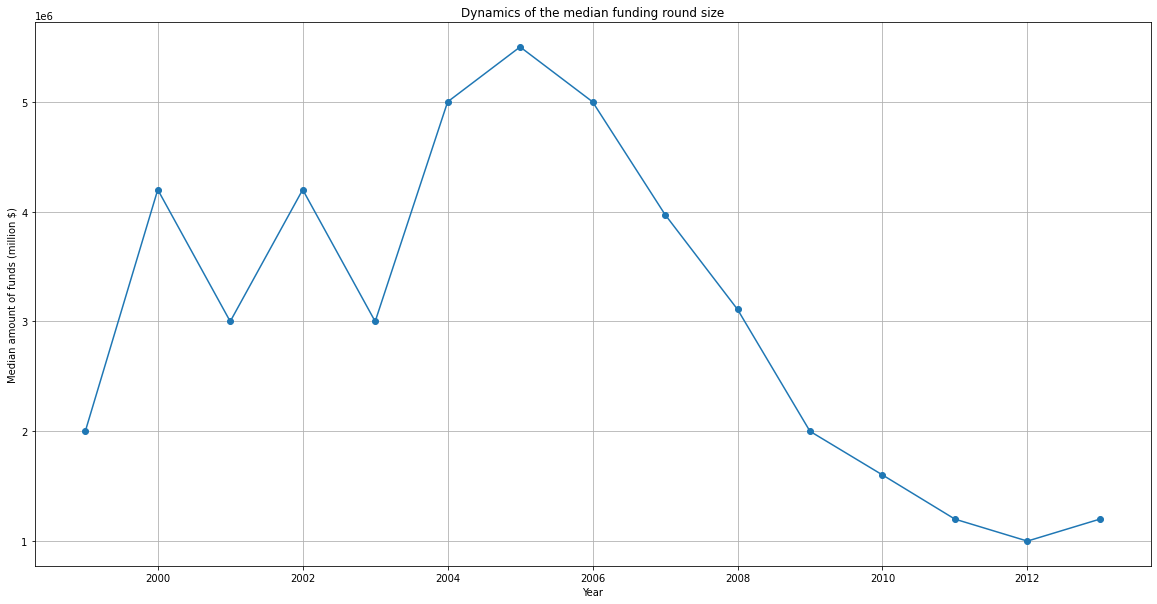

In [48]:
# Let's build a line chart of the median fund size by year
plt.figure(figsize=(20,10))
plt.plot(rounds_sum['year'], rounds_sum['median_amount'], marker='o')
plt.title("Dynamics of the median funding round size")
plt.xlabel("Year")
plt.ylabel("Median amount of funds (million $)")
plt.grid(True)
plt.show()

**The maximum typical size of funds raised in a single round was in 2005 and amounted to 5.5 million. In 2013, the number of rounds reached 11,072, which is the maximum compared to previous years; however, the median size of funds amounted to 1.2 million, which is significantly lower than the peak of 2004-2006 (5 million). In 2013, the market was characterized by an increase in the number of deals, but at the same time, a decrease in the average funding size.**


### 2.2. People and Their Education

The client wants to understand whether the completeness of information about employees (for example, about their education) depends on the size of the companies.

- Assess how complete the information about employees' education is. Using datasets `people.csv` and `education.csv`, Divide all companies into several groups based on the number of employees and estimate the average share of employees without education information in each group. Justify the chosen group boundaries.
- Evaluate whether it is possible to attach a table to these tables to complete the assignment `degrees.csv`.

In [50]:
# Let's output the dataset with information about employees
people_df.head(20)

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN
5,100002,Keith,Kurzendoerfer,NaN,NaN
6,100006,Courtney,Homer,81558.0,jobsbostontech
7,100009,Eddy,Badrina,NaN,NaN
8,100010,Michael,Dadashyan,NaN,fbroulette
9,100011,Jeff,Grell,NaN,NaN


In [51]:
# Let's display the dataset with information about the employee's education
education_df.head(20)

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaT
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaT
5,6,1017,Northeastern University,1988-01-01
6,7,6176,Rochester Institute of Technology,2002-01-01
7,8,5412,University of Cambridge,2002-01-01
8,9,1243,University of Oregon,1997-01-01
9,10,6265,University of Pennsylvania,1989-01-01


In [52]:
# Remove company_id gaps
people_new = people_df.dropna(subset=['company_id'])

# Counting the number of employees in each company
company_count = people_new.groupby('company_id').size().reset_index(name='num_employ')
company_count.head(30)

,company_id,num_employ
0,1.0,2
1,2.0,1
2,3.0,3
3,4.0,13
4,5.0,61
5,8.0,3
6,9.0,1
7,10.0,2
8,11.0,5
9,12.0,51


In [57]:
# Creating a label: whether there is education or not
education_yes = education_df.groupby('person_id').size().reset_index(name='education_count')
# every person_id in education_df has education
education_yes['has_education'] = 1  

# Let's combine with people
people_educ = people_new.merge(education_yes[['person_id', 'has_education']], left_on='id', right_on='person_id', how='left')
people_educ['has_education'] = people_educ['has_education'].fillna(0)  

In [58]:
# Assigning groups by company size
def size_group(n):
    if n <= 4:
        return 'Small (1-4)'
    elif n <= 14:
        return 'Medium (5-14)'
    elif n <= 50:
        return 'Large (15-50)'
    else:
        return 'Very large (51+)'

company_count['size_group'] = company_count['num_employ'].apply(size_group)

# Attach to people_educ
people_educ = people_educ.merge(company_count[['company_id', 'size_group']], on='company_id', how='left')

In [59]:
# Let's calculate the share of employees without education by group
educ_sum1 = (people_educ.groupby('size_group').agg(total_employees=('id', 'count'),with_education=('has_education', 'sum')))
educ_sum1['share_without_education'] = ((educ_sum1['total_employees'] - educ_sum1['with_education']) 
                                        / educ_sum1['total_employees'] * 100)
educ_sum1.head()

,total_employees,with_education,share_without_education
size_group,,,
Large (15-50),922,572.0,37.960954
Medium (5-14),4704,2282.0,51.488095
Small (1-4),28098,14974.0,46.707951
Very large (51+),891,636.0,28.619529


In [21]:
# Joining degrees to education by the id key
education_full = people_educ.merge(degrees_df, on='id', how='left')
education_full.head()

,id,first_name,last_name,company_id,network_username,person_id,has_education,size_group,object_id,degree_type,subject
0,10,Mark,Zuckerberg,5.0,NaN,10.0,1.0,Очень большая (51+),p:6265,BS,Economics
1,100,Peter,Lester,27.0,NaN,NaN,0.0,Средняя (5-14),p:938,BS,Computer Science
2,1000,Dr. Steven,E. Saunders,292.0,NaN,NaN,0.0,Маленькая (1-4),p:13098,MBA,NaN
3,10000,Neil,Capel,2526.0,NaN,NaN,0.0,Маленькая (1-4),p:74038,MS,Applied Mathematics
4,100006,Courtney,Homer,81558.0,jobsbostontech,100006.0,1.0,Маленькая (1-4),p:257617,BA,Political Science


**In small and medium-sized companies, almost half of the employees do not have education data (47–51%). In large companies, the share of employees without information is noticeably lower: in "big" companies — 38%, in "very large" companies — 29%. It is evident that the larger the company, the higher the likelihood that employees have their education details filled in. The degrees table expands information on the type and subject of education but does not affect completeness.**

### 2.3. To merge or not to merge — that is the question

Some column names appear in datasets more often than others. As a result of a preliminary dataset check, it was found that the `company_id` column is suitable for merging data.

- Determine whether the `network_username` column, which appears in several datasets, is suitable for merging data. We need to understand whether information in columns with this name is duplicated across different datasets, and if so — how often.
- Assess whether columns named `network_username` can be used for merging data.

In [60]:
# Let's count the number of unique 
for name, df in {"people": people_df, "company_and_rounds": company_and_rounds_df,}.items():
    if "network_username" in df.columns:
        print(f"{name}: {df['network_username'].nunique()} unique_from {df['network_username'].notna().sum()} non-empty")


people: 38421 unique_from 38867 non-empty
company_and_rounds: 79571 unique_from 95534 non-empty


In [61]:
# Checking the uniqueness and overlap of network_username
# Unique nicknames in each dataset
people_users = set(people_df['network_username'].dropna().unique())
company_users = set(company_and_rounds_df['network_username'].dropna().unique())
print("unique nicknames (people_df):", len(people_users))
print("unique nicknames (company_and_rounds_df):", len(company_users))

# Intersection
intersection = people_users & company_users
print("Coincidences:", len(intersection))
print("Percentage of Intersection :", round(len(intersection) / min(len(people_users), len(company_users)) * 100, 2), "%")

unique nicknames (people_df): 38421
unique nicknames (company_and_rounds_df): 79571
Coincidences: 2199
Percentage of Intersection : 5.72 %


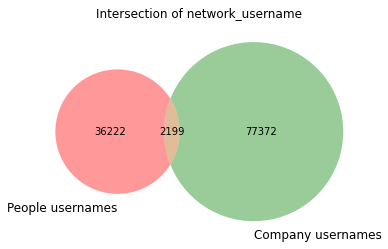

In [62]:
# Let's build a visualization of the intersection
venn2([people_users, company_users],
      set_labels=('People usernames', 'Company usernames'))
plt.title("Intersection of network_username")
plt.show()

**Conclusion: Both datasets contain the column network_username: in people_df these are people's nicknames, in company_and_rounds_df they are company nicknames. The intersection between the two sets is minimal in 2199 cases (5.72%). There are duplicates within each dataset, which can lead to a sharp increase in the number of rows and distortion of the analysis when merging. network_username cannot be used to merge the data. For accurate merging, it is better to use company_id.**


### 2.4. Problematic dataset and the reason for missing values

During their own data analysis, the client had the most questions about the dataset `company_and_rounds.csv`. It contains many missing values specifically in the information about rounds, which is important to the client.

- Using any convenient method, bring the data into a form that will allow analysis in terms of individual companies in the future. Pay attention to the dataset structure, the order and names of columns, and analyze the values.

According to the client's hypothesis, company data from this table was previously stored differently, in a way more convenient for research.

- While preserving the data as much as possible, maintaining its connectivity and avoiding any errors that could arise in the process, prepare the data so that it would be convenient to select companies by parameters and calculate metrics on a per-company basis without intermediate aggregations.

In [63]:
# Displaying information about the dataset
company_and_rounds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_ID           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [64]:
# Removing extra spaces from column names
df.columns = df.columns.str.strip().str.replace('  ', '_').str.replace(' ', '_')

# Checking the new names
print(df.columns)

Index(['company_ID', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id', 'funded_at', 'funding_round_type',
       'raised_amount', 'pre_money_valuation', 'participants',
       'is_first_round', 'is_last_round'],
      dtype='object')


In [65]:
# Let's split the company_and_rounds_df table into 2 related tables
# Companies table:
companies_new = df[[
    'company_ID', 'name', 'category_code', 'status', 'founded_at',
    'closed_at', 'domain', 'network_username', 'country_code',
    'investment_rounds', 'funding_rounds', 'funding_total', 'milestones'
]].drop_duplicates(subset=['company_ID']).reset_index(drop=True)

# Table of rounds:
rounds_new = df[[
    'funding_round_id', 'company_id', 'funded_at', 'funding_round_type',
    'raised_amount', 'pre_money_valuation', 'participants',
    'is_first_round', 'is_last_round'
]].dropna(subset=['funding_round_id']).reset_index(drop=True)


In [66]:
# Group the rounds table and aggregate by total funding and number of rounds per company
rounds_agg = rounds_new.groupby("company_id").agg(total_raised=("raised_amount", "sum"),
                                                  num_rounds=("funding_round_id", "count")).reset_index()
                                                     

# Merging with companies_new
companies_full = companies_new.merge(rounds_agg, left_on="company_ID", right_on="company_id", how="left")
companies_full.drop(columns=["company_id"], inplace=True)
companies_full.head()

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,total_raised,num_rounds
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,39750000.0,3.0
1,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0,NaN,NaN
2,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0,NaN,NaN
3,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
4,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN


**It can be concluded that company_and_rounds_df is stitched together from two tables because: there are two different identifiers, company_ID — the company identifier, and funding_round_id — the round identifier. The data in it have different levels of detail: part describes the company, part the specific funding round. Fields often contain missing values or are duplicated if a company has several rounds. Therefore, in this task, we separated it into two tables for analyzing individual companies and separate rounds. We calculated the total funding total_raised and the number of rounds num_rounds per company. We combined the aggregated indicators with the companies table companies_full. Connectivity and correctness were preserved, missing values for rounds were not removed from companies, and rows of companies without rounds remained.**


## Шаг 3. Exploratory analysis of combined tables



### 3.1. Data Consolidation

Consolidate the data to answer the client's questions concerning the companies of interest to them. The client is primarily interested in companies that have changed or are willing to change owners. According to the client, receiving investment or funding indicates interest in buying or selling the company.

As a basis for the consolidated table, use data from the processed dataset `company_and_rounds.csv` — select only those companies that have `funding_rounds` or `investment_rounds` values greater than zero, or those whose `status` column indicates `acquired`. The resulting table should contain about 40 thousand companies.

Check the completeness and accuracy of the resulting table. Then work only with this data.

In [67]:
# # Filtering by conditions
companies_filtered = companies_full[ (companies_full["funding_rounds"] > 0) | (companies_full["investment_rounds"] > 0) |
                     (companies_full["status"] == "acquired")].reset_index(drop=True)
# Let's output the filtered data
print(companies_filtered.shape)
companies_filtered.head()

(40747, 15)


,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,total_raised,num_rounds
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,39750000.0,3.0
1,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0,NaN,NaN
2,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0,NaN,NaN
3,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0,5000000.0,1.0
4,10014.0,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0.0,1.0,0.0,4.0,0.0,1.0



### 3.2. Outlier Analysis

The client is interested in the typical amount of funds provided to companies for the period under consideration.

- Using the preprocessed `funding_total` column, visually assess what total funding amount for a single company would be typical and what would be an outlier.
- During the calculation of values, pay attention, for example, to the indicators returned by the `.describe()` method — explain them. Are the usual methods for finding typical values applicable to such data?

In [68]:
# Let's evaluate the data funding_total
companies_filtered["funding_total"].describe()

count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+05
75%      5.650650e+06
max      5.700000e+09
Name: funding_total, dtype: float64

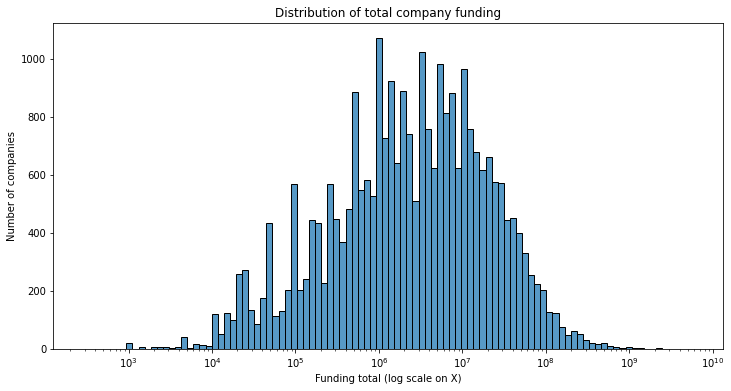

In [69]:
# Let's build a histogram of total company funding
plt.figure(figsize=(12,6))
sns.histplot(companies_filtered["funding_total"][companies_filtered["funding_total"] > 0],
    bins=100,
    log_scale=(True, False)
)
plt.xlabel("Funding total (log scale on X)")
plt.ylabel("Number of companies")
plt.title("Distribution of total company funding")
plt.show()

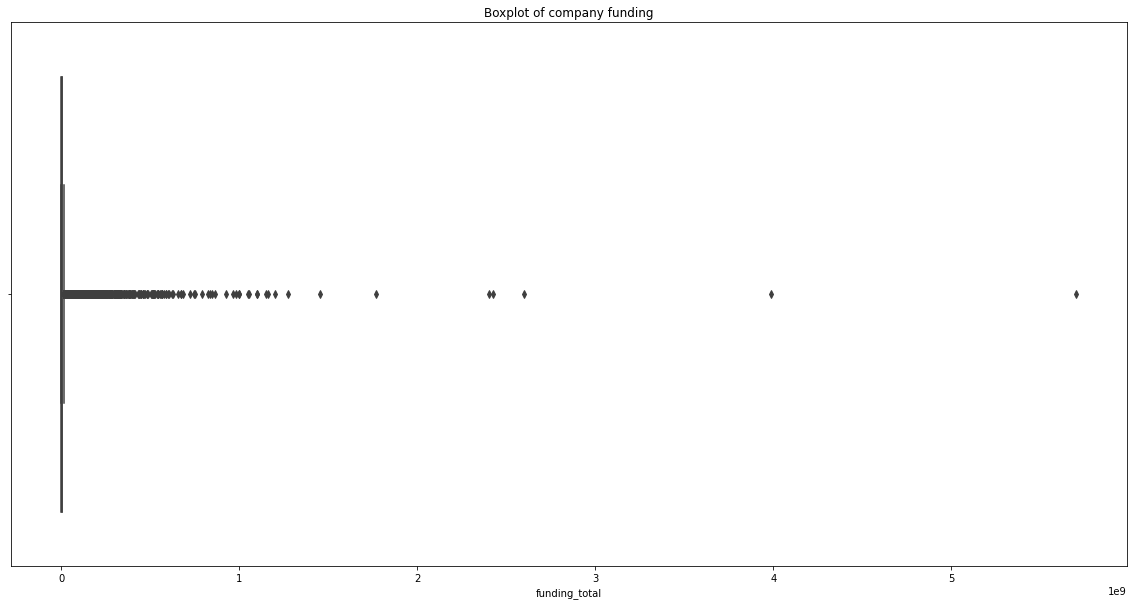

In [70]:
# # Let's build a boxplot to assess the outliers of the funding amount
plt.figure(figsize=(20,10))
sns.boxplot(x=companies_filtered["funding_total"].dropna())
plt.xlabel("funding_total")
plt.title("Boxplot of company funding")
plt.show()

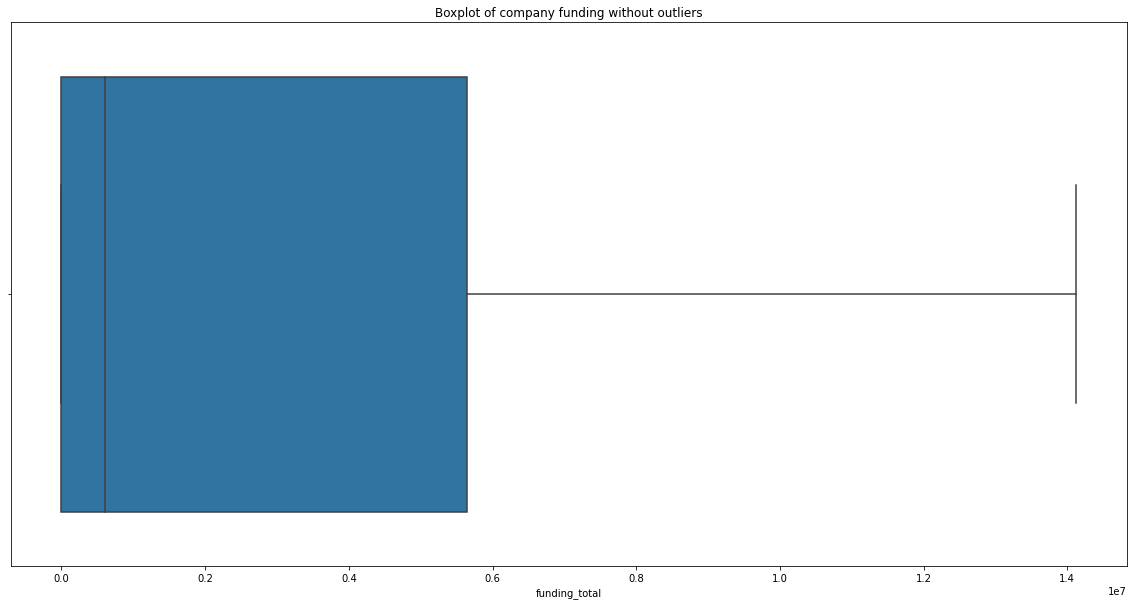

In [71]:
# Let's build a company funding boxplot without outliers
plt.figure(figsize=(20,10))
sns.boxplot(x=companies_filtered["funding_total"].dropna(), showfliers=False)
plt.xlabel("funding_total")
plt.title("Boxplot of company funding without outliers")
plt.show()

**The difference between the mean of approximately 10 million and the median of 0.6 million is large. Based on descriptive statistics, the distribution is skewed to the right; most companies received relatively small amounts, while rare large investments distort the mean. Therefore, it is important for the client to focus not on the mean, but on the median and the interquartile range. 
The histogram shows that the typical range of investments is approximately between 0.1 million and 10 million. 
The boxplot shows an almost continuous line at zero and several distant outlier points (tens and hundreds of millions, as well as billions). Most companies fall within a range up to a few million.**
**Conclusion:
The typical (average) funding size for companies during the period under consideration ranges from hundreds of thousands to several million dollars.
Outliers include large investments of tens and hundreds of millions, as well as individual cases reaching billions.
Standard methods of calculating the average are not suitable here, as they are distorted by outliers.
It is more appropriate to use the median and interquartile range, as well as charts.**



### 3.3. Bought for free?

- Explore companies that were sold for zero or one dollar, while it is known that they had a non-zero total funding amount.

- Analytically calculate the upper and lower bounds of outliers for the `funding_total` column and indicate which percentiles the bounds correspond to.

In [72]:
# Merging company and deal tables by company_ID
df_merge = companies_filtered.merge(
    acquisition_df,
    left_on='company_ID',
    right_on='acquired_company_id',
    how='left'
)
# Filter companies by conditions:
new_acquired = df_merge[
    (df_merge['status'] == 'acquired') &
    (df_merge['price_amount'] < 2) &
    (df_merge['funding_total'] != 0)
].copy()
new_acquired.shape, new_acquired.head(3)

((1618, 21),
     company_ID        name category_code    status founded_at closed_at  \
 25     10054.0     Jumptap        mobile  acquired 2005-01-01       NaT   
 63    101312.0    SideTour           web  acquired 2011-06-01       NaT   
 66    101340.0  ChoicePass    enterprise  acquired 2011-07-01       NaT   
 
             domain network_username country_code  investment_rounds  ...  \
 25     jumptap.com          jumptap          USA                0.0  ...   
 63    sidetour.com         sidetour          USA                0.0  ...   
 66  choicepass.com       choicepass          USA                0.0  ...   
 
     funding_total  milestones  total_raised  num_rounds      id  \
 25    121500000.0         3.0   121500000.0         7.0  9288.0   
 63      4000000.0         2.0     4000000.0         3.0  9653.0   
 66       250000.0         1.0      250000.0         1.0  7272.0   
 
     acquiring_company_id  acquired_company_id       term_code price_amount  \
 25               

In [35]:
# Let's check the number of duplicates
new_acquired['company_ID'].duplicated().sum()

25

In [73]:
# Let's look at the duplicates ourselves
dupls = new_acquired[new_acquired['company_ID'].duplicated(keep=False)].sort_values('company_ID')
dupls[["company_ID", "name", "price_amount", "funding_total", "acquired_at"]]

,company_ID,name,price_amount,funding_total,acquired_at
1237,130.0,KickApps,0.0,39007800.0,2011-01-31
1238,130.0,KickApps,0.0,39007800.0,2012-12-12
28527,431.0,TimeBridge,0.0,12400000.0,2011-06-22
28526,431.0,TimeBridge,0.0,12400000.0,2010-09-21
29104,445.0,Six Apart,0.0,22600000.0,2011-01-31
29103,445.0,Six Apart,0.0,22600000.0,2010-11-24
39034,800.0,Social Project,0.0,47500000.0,2010-10-10
39033,800.0,Social Project,0.0,47500000.0,2008-09-22
40351,867.0,GamerDNA,0.0,3000000.0,2009-12-21
40352,867.0,GamerDNA,0.0,3000000.0,2011-07-19


In [37]:
# Calculation of emission limits for funding_total
Q1 = companies_filtered["funding_total"].quantile(0.25)
Q3 = companies_filtered["funding_total"].quantile(0.75)
iqr = Q3 - Q1

lower_bound = Q1 - 1.5 * iqr
upper_bound = Q3 + 1.5 * iqr

def get_percentile(value, series):
    return (series < value).mean() * 100

lower_percentile = get_percentile(lower_bound, companies_filtered["funding_total"])
upper_percentile = get_percentile(upper_bound, companies_filtered["funding_total"])

lower_bound, lower_percentile, upper_bound, upper_percentile

(-8475975.0, 0.0, 14126625.0, 85.62348148329939)

***Conclusions  
We analyzed companies that were acquired for a symbolic price (0 dollar or 1 dollar) despite having a non-zero total funding amount.  
To conduct this analysis, we merged company-level data with acquisition records.  
During the merging process, duplicate records by company_ID appeared in the resulting dataset. Further investigation showed that companies may appear multiple times because they were acquired more than once — on different dates (acquired_at) and potentially under different deal terms.  
Therefore, these are not true duplicates but repeated acquisition events.  
They can either:  
Be retained in the dataset (to reflect all transactions), or
Be filtered (for example, by keeping only the first or the most recent acquisition per company), depending on the analytical objective.  
Outlier Boundaries for funding_total:  
Using the IQR method:  
The lower bound turned out to be negative.  
Since negative funding is not possible in real-world data, the effective lower bound is set to 0, corresponding to the 0th percentile.  
The upper bound was approximately 14 million dollars, corresponding roughly to the 85th percentile.  
Final Interpretation:  
The typical total funding range for companies prior to acquisition is between 0 and 14 million dollars.  
Values above this threshold can be considered outliers.***  


### 3.4. Startup Prices by Category

Categories of startups with typically high purchase prices and significant price variation can be attractive to large investors who are ready for high risks in exchange for potentially large returns. Among the categories of startups, highlight the categories of startups characterized by:

- typically high prices;
- and the greatest price variation per startup.

Explain why you decided to make a top list from exactly this number of categories and why you calculated it in this way.

In [76]:
# To calculate the interquartile range (IQR) we use the scipy.stats.iqr 
from scipy.stats import iqr
# We take only the companies that were actually acquired
acquired_df = df_merge[(df_merge['status'] == 'acquired') & (df_merge['price_amount'] > 0)].copy()
# Группируем по категориям стартапов
category_stats = acquired_df.groupby("category_code").agg(
    median_price=("price_amount", "median"),
    iqr_price=("price_amount", iqr),
    std_price=("price_amount", "std"),
    count=("price_amount", "count")
).reset_index()
# Group by startup categories
top_categories = category_stats.sort_values(["median_price", "iqr_price"], ascending=False)

In [77]:
# Filter categories with a sufficient number of observations (for example, > 30 companies)
category_stats = category_stats[category_stats["count"] > 5]
# Top 10 by median
top_by_median = category_stats.sort_values("median_price", ascending=False).head(10)
# Top 10 by spread (IQR)
top_by_iqr = category_stats.sort_values("iqr_price", ascending=False).head(10)

In [78]:
# Let's list the top startup categories with high deal prices (by median)
top_by_median.head(10)

,category_code,median_price,iqr_price,std_price,count
27,real_estate,400000000.0,9.700000e+08,2.676302e+09,6
16,manufacturing,351000000.0,1.240000e+09,1.060435e+09,21
3,biotech,200000000.0,4.690000e+08,1.968195e+09,263
4,cleantech,185000000.0,2.780000e+08,8.744196e+08,39
10,finance,171500000.0,5.419000e+08,1.052920e+09,20
29,security,164500000.0,4.462500e+08,1.378442e+09,36
6,ecommerce,157500000.0,3.365375e+08,2.814255e+08,50
13,health,140000000.0,3.135000e+08,1.927100e+09,10
26,public_relations,110000000.0,3.893750e+08,6.854338e+09,74
22,network_hosting,102500000.0,3.247750e+08,6.769568e+08,64


In [79]:
# Let's display the top startup categories with the largest price range (by IQR)
top_by_iqr.head(10)

,category_code,median_price,iqr_price,std_price,count
16,manufacturing,351000000.0,1.240000e+09,1.060435e+09,21
27,real_estate,400000000.0,9.700000e+08,2.676302e+09,6
10,finance,171500000.0,5.419000e+08,1.052920e+09,20
3,biotech,200000000.0,4.690000e+08,1.968195e+09,263
29,security,164500000.0,4.462500e+08,1.378442e+09,36
26,public_relations,110000000.0,3.893750e+08,6.854338e+09,74
14,hospitality,57500000.0,3.575500e+08,7.906006e+08,7
6,ecommerce,157500000.0,3.365375e+08,2.814255e+08,50
22,network_hosting,102500000.0,3.247750e+08,6.769568e+08,64
24,other,71550000.0,3.200000e+08,2.060861e+09,84


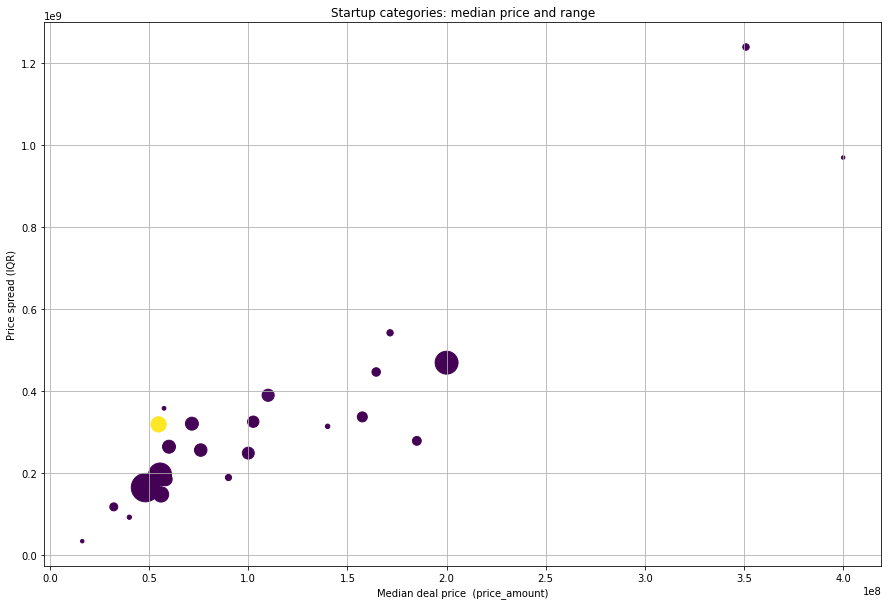

In [80]:
plt.figure(figsize=(15, 10))
# строим scatter
scatter = plt.scatter(
    category_stats["median_price"],
    category_stats["iqr_price"],
    s=category_stats["count"]*2,
    c=category_stats["std_price"],
    cmap="viridis",
)
plt.xlabel("Median deal price  (price_amount)")
plt.ylabel("Price spread (IQR)")
plt.title("Startup categories: median price and range")
plt.grid(True)
plt.show()

***We highlighted the top 10 categories by median startup price and the top 10 categories by price dispersion. The median was chosen as an indicator of a typical price since it is resistant to outliers, which distort the mean. Dispersion was assessed using the interquartile range (IQR), as it more reliably shows price variability without being influenced by single-billion-dollar deals. The top 10 was chosen to highlight leaders in price and dispersion, as a larger number of categories could overload the analysis.
Categories with high deal prices:
The top included real_estate (400M), manufacturing (351M), biotech (200M), cleantech, finance, security, ecommerce, health, public_relations, network_hosting.
These categories are characterized by median prices in the hundreds of millions of dollars (from 100M to 400M).
This means that buyers are usually willing to pay large sums for companies in these sectors.
Categories with the largest price dispersion:        
В топ попали manufacturing, real_estate, finance, biotech, security, public_relations, hospitality, ecommerce, network_hosting.    
The high variance indicates that deals in these categories differ greatly in value: from relatively small purchases to billion-dollar ones. This is a sign that the market is unstable and that company valuation heavily depends on the specific startup.***  


### 3.5. How many rounds will a startup last before acquisition

- It is necessary to analyze the `funding_rounds` column. Examine the values of the column. The client is interested in the typical number of rounds for each possible startup status.
- Create a chart that shows the average number of funding rounds for startups in each group. Draw conclusions.

In [81]:
# Let's calculate the average and median number of rounds for each startup status
rounds_by_status = companies_filtered.groupby("status")["funding_rounds"].agg(["mean", "median", "count"]).reset_index()
print(rounds_by_status)

      status      mean  median  count
0   acquired  0.523526     0.0   9394
1     closed  1.381453     1.0   2092
2        ipo  1.934375     1.0    640
3  operating  1.522658     1.0  28621


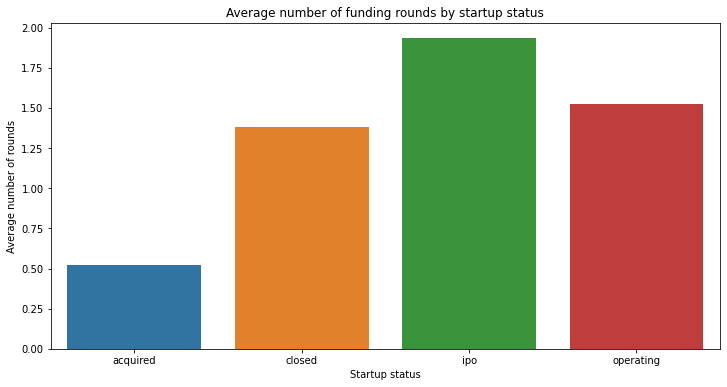

In [82]:
# Let's build a bar chart of the average number of funding rounds by startup status
plt.figure(figsize=(12,6))
sns.barplot(data=rounds_by_status, x="status", y="mean")
plt.title("Average number of funding rounds by startup status")
plt.xlabel("Startup status")
plt.ylabel("Average number of rounds")
plt.show()

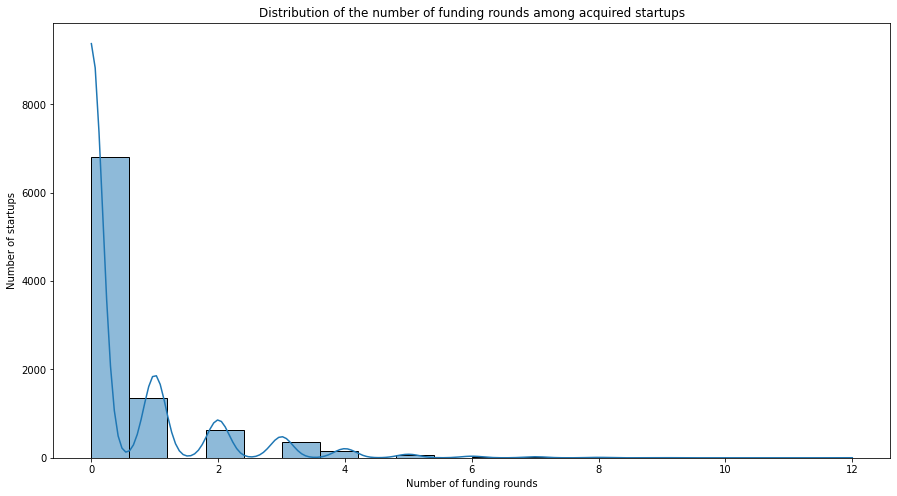

In [83]:
# We only take purchased startups
acquired_rounds = companies_filtered.loc[companies_filtered["status"] == "acquired", "funding_rounds"].dropna()
# Let's build a histogram or density plot of the number of rounds for startups that were acquired.
plt.figure(figsize=(15,8))
sns.histplot(acquired_rounds, bins=20, kde=True)
plt.xlabel("Number of funding rounds")
plt.ylabel("Number of startups")
plt.title("Distribution of the number of funding rounds among acquired startups")
plt.show()

***Conclusion: Acquired - companies that were acquired went through an average of 0.5 funding rounds (median = 0).   This means that a significant portion of such startups were sold before attracting substantial external financing.   Closed - closed companies had an average of 1.38 rounds (median = 1). That is, they managed to attract at least one round, but usually not more. IPO - companies that reached IPO go through an average of 1.93 rounds (median = 1).   This indicates that even reaching the stock market does not always require many rounds, but they more often attract slightly more than closed or acquired companies.   
Operating companies have on average 1.52 rounds (median = 1). That is, they usually continue to raise funds, and in the future they may have additional rounds.    
The minimum number of rounds for acquired companies - startups are often purchased earlier before they have gone through a long funding cycle.    
The maximum number of rounds for operating companies - they develop independently for a longer period.    
Conclusions on startup acquisitions depending on the number of funding rounds conducted:    
Most acquired startups go through 0–2 funding rounds, with the highest concentration observed exactly at the early stages.    
The peak at 0 rounds indicates that some startups are bought even before attracting external investments — their value lies in technology or the team, not in their financing history. After 3–4 rounds, the frequency of deals drops sharply, indicating a low probability of acquisition at later stages. A small number of deals also occur after a large number of rounds (outliers on the right), but such cases are extremely rare.***    


## Step 4. Final Conclusions and Recommendations


***Key Findings  
1️⃣ Data Preprocessing:  
Inconsistencies in column names were identified (company_ID vs. company_id).  
Duplicates were found in network_username.  
For further analysis, we retained only companies that either had recorded funding or an acquired status — approximately 40,000 companies.  
This ensured analytical relevance and removed inactive or incomplete entities.  
2️⃣ Funding Analysis:    
The distribution of total funding is strongly right-skewed:  
Most companies raised up to a few million dollars.  
Very large investments (tens or hundreds of millions, and occasionally billions) are rare and represent outliers.  
Typical funding range:  
From several hundred thousand dollars up to 10–14 million dollars.  
For identifying “normal” values, the median and interquartile range (IQR) are more appropriate than the mean due to extreme right skewness.  
3️⃣ Anomalous Cases (Acquired for 0 or 1 dollar):  
We analyzed companies that were acquired for symbolic amounts (0 or 1 dollar) despite having non-zero total funding. 
To conduct this analysis, company-level data was merged with acquisition records.  
During merging, duplicate records by company_ID appeared. Further investigation revealed that these were not true duplicates, but multiple acquisition events — companies were sold more than once, on different dates (acquired_at) and possibly under different conditions.  
Therefore:  
These records can be retained to reflect all transactions,  
Or filtered (e.g., keeping only the first or latest acquisition), depending on the business objective.  
Outlier Boundaries for funding_total  
Using the IQR method:  
The lower bound was negative. Since negative funding is impossible in practice, the effective lower bound was set to 0 (0th percentile).  
The upper bound was approximately 14 million dollars, corresponding roughly to the 85th percentile.  
Conclusion:  
The typical total funding range before acquisition is 0–14 million dollars.  
Values above this threshold can be considered outliers.  
4️⃣ Categories with High Acquisition Prices:   
Top categories by median acquisition price:  
-Real Estate (~400M)  
-Manufacturing (~351M)  
-Biotech (~200M)  
-Cleantech  
-Finance  
-Security  
-Ecommerce  
-Health  
-Public Relations  
-Network Hosting  
These categories show median deal values in the hundreds of millions of dollars, indicating strong investor willingness to pay premium prices in these sectors.  
Categories with the Highest Price Variability:  
-Manufacturing  
-Real Estate  
-Finance  
-Biotech  
-Security  
-Public Relations  
-Hospitality  
-Ecommerce  
-Network Hosting     
High variability indicates substantial deal dispersion — from moderate acquisitions to billion-dollar transactions.  
This reflects high-risk / high-reward market environments, where company valuation depends heavily on the specific startup.  
5️⃣ Funding Rounds by Company Status:  
Acquired companies are typically purchased at early stages (median = 0 rounds).  
Closed companies usually complete 1 funding round before shutting down.  
IPO and Operating companies tend to have more funding rounds (≈2 and ≈1.5 on average), reflecting longer growth trajectories.  
Acquisition Probability by Number of Funding Rounds  
Most acquired startups complete 0–2 funding rounds.  
A peak at 0 rounds indicates that some startups are acquired before raising external funding — their value lies in technology or team rather than funding history.  
After 3–4 rounds, acquisition frequency drops sharply.  
A small number of acquisitions occur after many rounds (right-tail outliers), but such cases are rare.  
Strategic Recommendations:  
1️⃣ Focus on Early-Stage Startups:
Many acquisitions occur before significant funding.  
Early-stage targeting may provide better entry opportunities and higher ROI potential.  
2️⃣ Avoid Overvalued Outliers  
Large deals (tens or hundreds of millions) are statistical outliers and may not represent typical market value.  
3️⃣ Invest in High-Potential Categories  
Categories that consistently show both high median prices and strong variability include:  
-Manufacturing  
-Real Estate  
-Biotech  
-Finance  
-Security  
-Public Relations  
-Ecommerce  
-Network Hosting  
These sectors may be attractive for investors willing to accept higher risk for potentially high returns.  
4️⃣ Use Funding Rounds as a Lifecycle Indicator  
Companies with no or few rounds are more frequently acquired.  
Companies with multiple rounds are more likely to reach IPO or continue operating independently.  
5️⃣ Carefully Evaluate Zero-Price Deals  
Acquisitions for 0 often involve distressed assets or strategic acquisitions where value exists only within a larger corporate structure.***    